# Analiza zbioru Heart Disease - Regresja Liniowa
## Model regresji liniowej
W analizie wykorzystana zostanie regresja liniowa.<br>
Metoda ta z założenia słuzy do przewidywania wartości ciągłych a nie binarnych, więc należy zdefiniować próg między chorym a zdrowym pacjentem.<br>
W zbiorze "Heart Disease" można interpretować to jako stopień zaawansowania choroby.
## Próg odcięcia
Regresja liniowa nie zwraca bezpośrednio przynależności do klasy, więc konieczne było zdefiniowanie progu odcięcia.<br>
Dla wyliczenia pola pod wykresem (AUC) roc_curve testuje wszystkie progi, dlatego nie było konieczne definiowanie progu "na sztywno"
## Braki w danych
W zbiorze danych występują braki w kolumnach ca oraz thal.<br>
Usunięcie nieprawidłowych danych skutkowałoby zmniejszoną dokładnością modelu (zbiór Heart Disease i tak jest nieduży).<br>
Dla kolumny ca (numerycznej) wykorzystane zostało uśrednienie cechy.<br>
Dla kolumny thal (kategorycznej) wykorzystana została metoda most_frequent.<br>
Choć "sztuczne" wypełnienie danych pomaga zachować kompletność zbioru, to jest to pewne uproszczenie rzeczywistości.<br>


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, roc_curve, auc
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def load_data():
    columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
               'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    return pd.read_csv(url, names=columns, na_values='?')

def plot_eda(df):
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
    plt.title("Macierz korelacji cech")
    plt.show()
    
    df['target'].value_counts().plot(kind='bar', title='Rozkład zmiennej celu')
    plt.show()

## Analiza korelacji cech

Poniższa mapa ciepła przedstawia macierz korelacji dla zmiennych numerycznych w zbiorze Heart Disease.<br>
Pozwala ona ocenić zależność między poszczególnymi parametrami.<br>
- Silne korelacje: Wysoka korelacja między zmiennymi może sugerować nadmiar informacji, co w regresji liniowej bywa problematyczne (model może mieć trudności z przypisaniem wag)
- Związek z celem: Szukałem cech, które mają największy związek ze zmienną target (mają największy wpływ na wyniki modelu)
Analiza korelacji wykazała, że zmienne ca, thal oraz oldpeak mają najistotniejszy wpływ na target.

Braki w danych:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Statystyki zbioru:
               age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     t

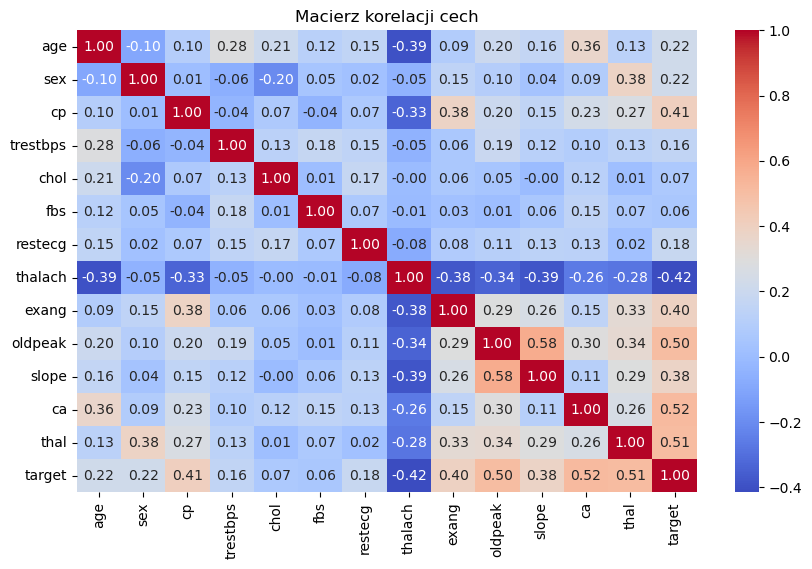

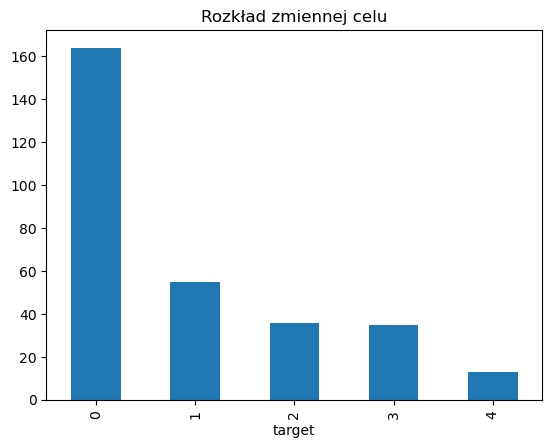

In [21]:
df = load_data()

print("Braki w danych:\n", df.isnull().sum())
print("\nStatystyki zbioru:\n", df.describe())

plot_eda(df)

X = df.drop('target', axis=1)
y = df['target']

num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), num_features),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features)
])

Mean Squared Error: 1.0021


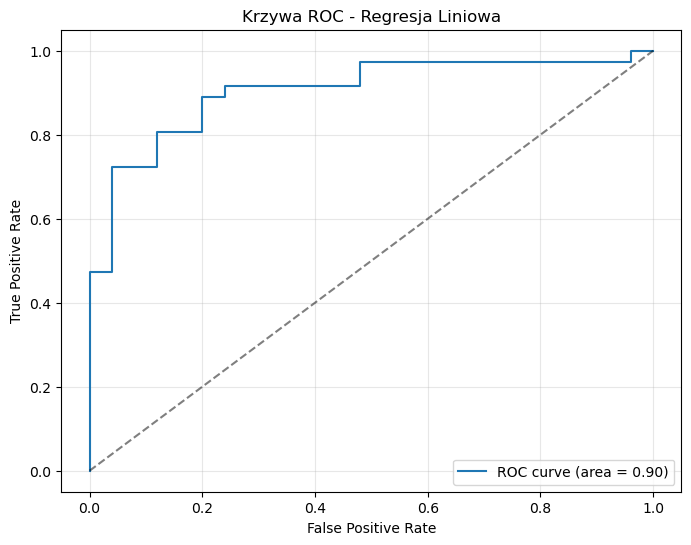

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

y_test_bin = (y_test > 0).astype(int)
fpr, tpr, _ = roc_curve(y_test_bin, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - Regresja Liniowa')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [23]:
regressor = model_pipeline.named_steps['regressor']
feature_names = num_features + list(model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features))
coefs = pd.DataFrame({'cecha': feature_names, 'waga': regressor.coef_})
print(coefs.sort_values(by='waga', ascending=False))

          cecha      waga
15  restecg_1.0  0.443499
5            ca  0.414004
11       cp_4.0  0.354040
24     thal_7.0  0.300235
4       oldpeak  0.184335
21    slope_3.0  0.140091
18    exang_1.0  0.129363
1      trestbps  0.109153
7       sex_1.0  0.107084
9        cp_2.0  0.098803
20    slope_2.0  0.042506
12      fbs_0.0  0.002646
13      fbs_1.0 -0.002646
2          chol -0.004709
0           age -0.038587
10       cp_3.0 -0.051217
16  restecg_2.0 -0.104337
6       sex_0.0 -0.107084
23     thal_6.0 -0.122664
17    exang_0.0 -0.129363
3       thalach -0.140636
22     thal_3.0 -0.177571
19    slope_1.0 -0.182598
14  restecg_0.0 -0.339162
8        cp_1.0 -0.401626


## Interpretacja wag
Dzięki zastosowaniu StandardScaler wagi są bezpośrednio porównywalne. Możemy przez to obiektywnie stwierdzić, która cecha ma większe znaczenie przy klasyfikacji pacjenta.

Wartości wag wskazują na kierunek oraz siłę wpływu poszczególnych cech na stan pacjenta:
- Cechy o największych wartościach (np. restecg_1.0, ca) mają największy wpływ na wzrost wartości predykcji. Model interpretuje je jako najbardziej promujące wystąpienie choroby
- Cechy o najmniejszych wartościach (np. cp_1.0, restecg_0.0) działają w przeciwną stronę
- Zmienne których wagi są bliskie zeru mają minimalny wpływ na decyzję modelu

## Wnioski z eksperymentu
1. **Jakość danych:** Zbiór posiadał nieliczne braki w kolumnach `ca` oraz `thal`, które uzupełniono przy użyciu imputacji statystycznej.
2. **Wyniki modelu:** Regresja liniowa osiągnęła AUC na poziomie 0,90. Jest to wynik akceptowalny.
3. **Wizualizacja:** Krzywa ROC pokazuje zdolność modelu do rozróżniania pacjentów chorych od zdrowych przy różnych progach odcięcia dla wyniku regresji.